## Assignment 1 — Image Interpolation



In [ ]:
import cv2
import time
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

input_path = Path("/content/drive/MyDrive/AIPA_HA/ALM-3/Interpolation.jpg")
output_dir = Path("/content/drive/MyDrive/AIPA_HA/ALM-3/Assignment_1_Interpolation")
output_dir.mkdir(parents=True, exist_ok=True)

image = cv2.imread(str(input_path), cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError(f"Image not found: {input_path}")

height, width = image.shape
new_size = (width * 2, height * 2)

cv2.imwrite(str(output_dir / "original.png"), image)

methods = {
    "Nearest Neighbor": cv2.INTER_NEAREST,
    "Bilinear": cv2.INTER_LINEAR,
    "Bicubic": cv2.INTER_CUBIC
}

results = []

for name, method in methods.items():
    start_time = time.perf_counter()

    resized = cv2.resize(
        image,
        new_size,
        interpolation=method
    )

    elapsed_time = time.perf_counter() - start_time

    filename = name.lower().replace(" ", "_") + ".png"
    cv2.imwrite(str(output_dir / filename), resized)

    results.append((name, elapsed_time))

print("Original size:", image.shape)
print("Resized size:", (new_size[1], new_size[0]))

print("\nComputational time:")
for name, elapsed_time in results:
    print(f"{name}: {elapsed_time:.8f} seconds")

print("\nOutput files saved in:")
print(output_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original size: (282, 179)
Resized size: (564, 358)

Computational time:
Nearest Neighbor: 0.01397476 seconds
Bilinear: 0.01365839 seconds
Bicubic: 0.02209136 seconds

Output files saved in:
/content/drive/MyDrive/AIPA_HA/ALM-3/Assignment_1_Interpolation


## Display teh results

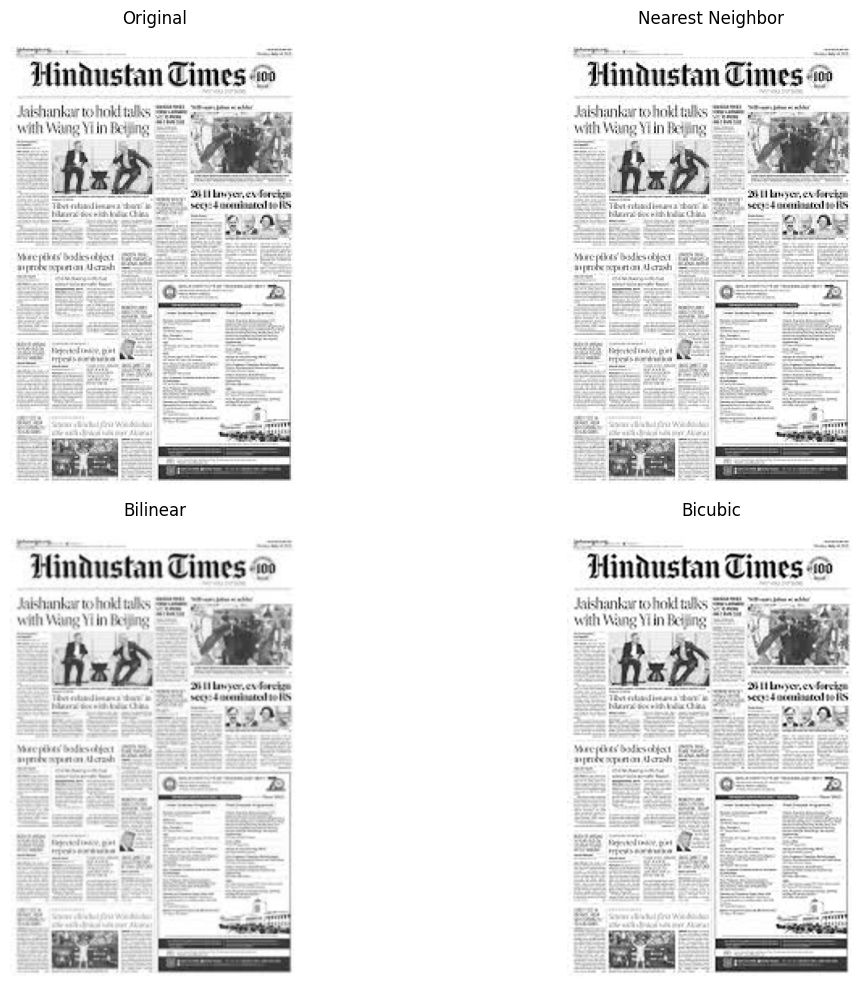

In [ ]:
import matplotlib.pyplot as plt

original = cv2.imread(str(output_dir / "original.png"), cv2.IMREAD_GRAYSCALE)
nearest = cv2.imread(str(output_dir / "nearest_neighbor.png"), cv2.IMREAD_GRAYSCALE)
bilinear = cv2.imread(str(output_dir / "bilinear.png"), cv2.IMREAD_GRAYSCALE)
bicubic = cv2.imread(str(output_dir / "bicubic.png"), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.imshow(original, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(nearest, cmap="gray")
plt.title("Nearest Neighbor")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(bilinear, cmap="gray")
plt.title("Bilinear")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(bicubic, cmap="gray")
plt.title("Bicubic")
plt.axis("off")

plt.tight_layout()
plt.show()

## Assignment 2 — Histogram Equalization

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Image 1: Histogram_image_1.png
Image 2: Histogram_image_2.jpg


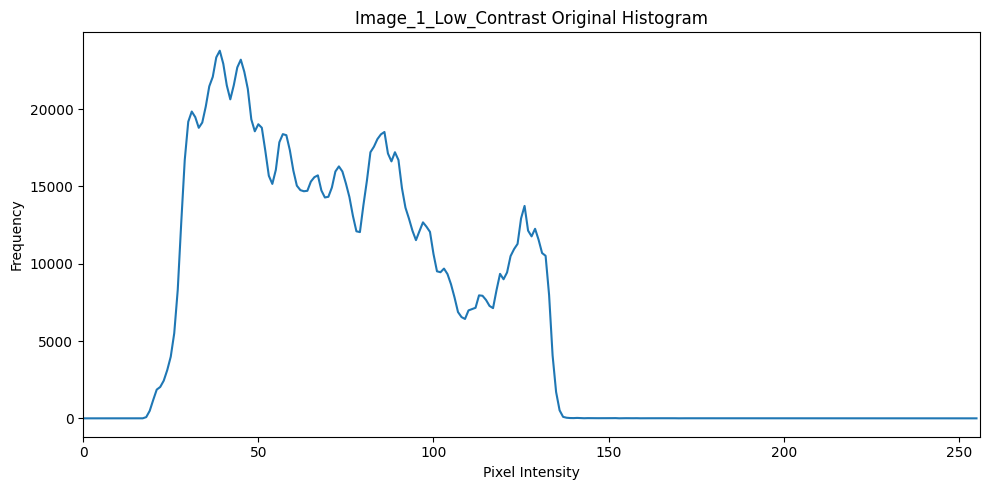

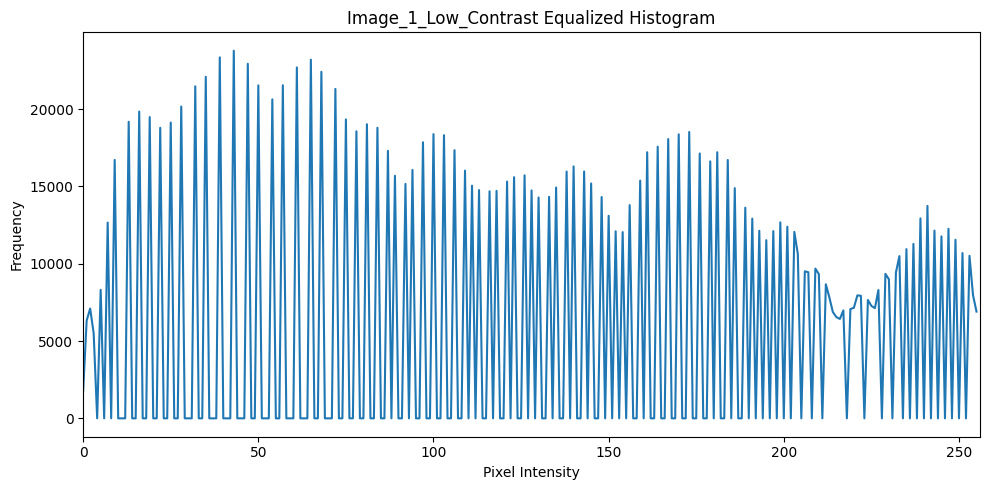


Image_1_Low_Contrast
Original mean: 71.87
Original standard deviation: 30.44
Equalized mean: 128.77
Equalized standard deviation: 73.33


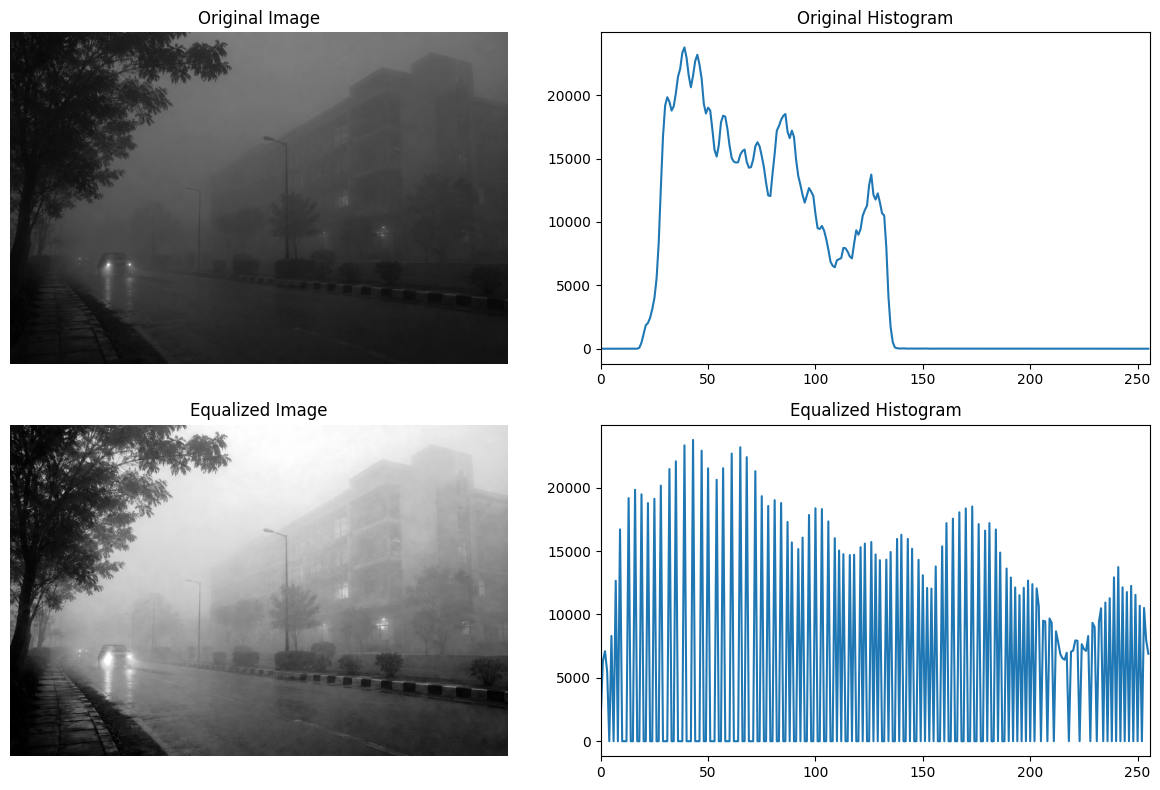

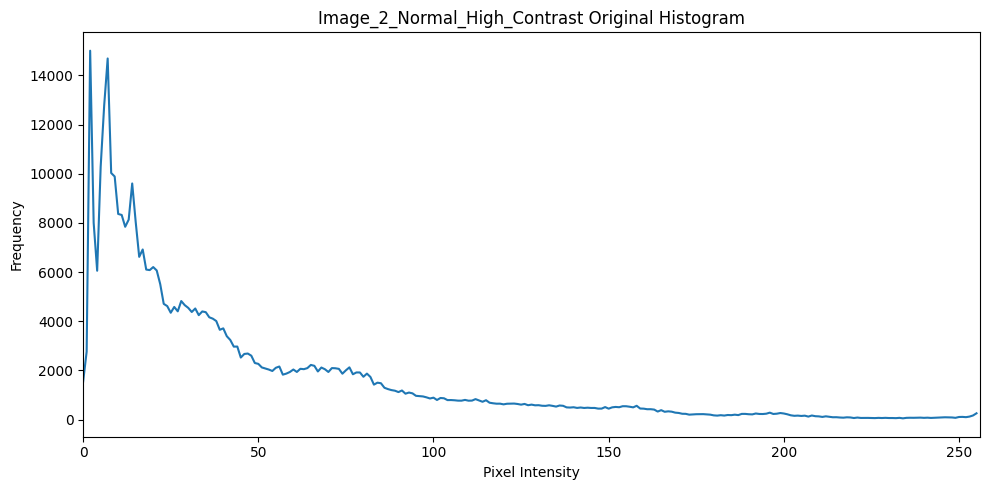

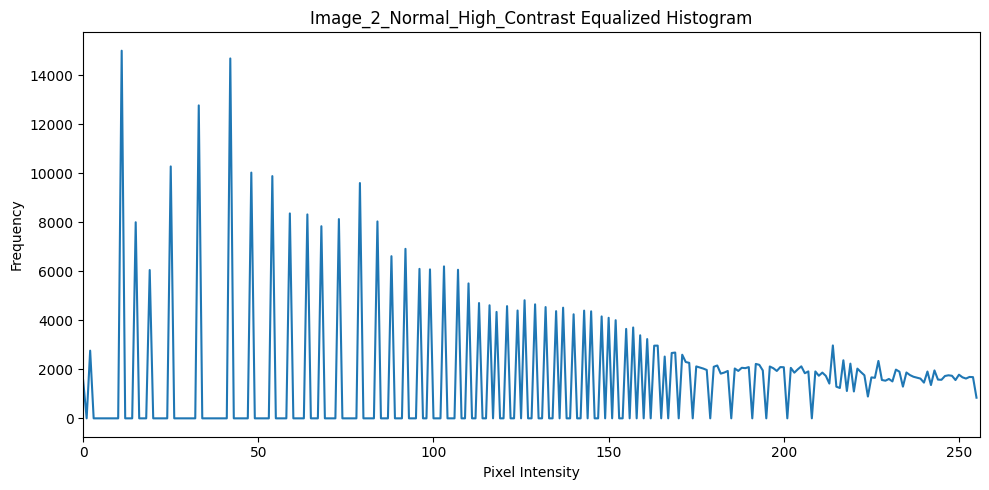


Image_2_Normal_High_Contrast
Original mean: 45.24
Original standard deviation: 46.77
Equalized mean: 128.7
Equalized standard deviation: 72.73


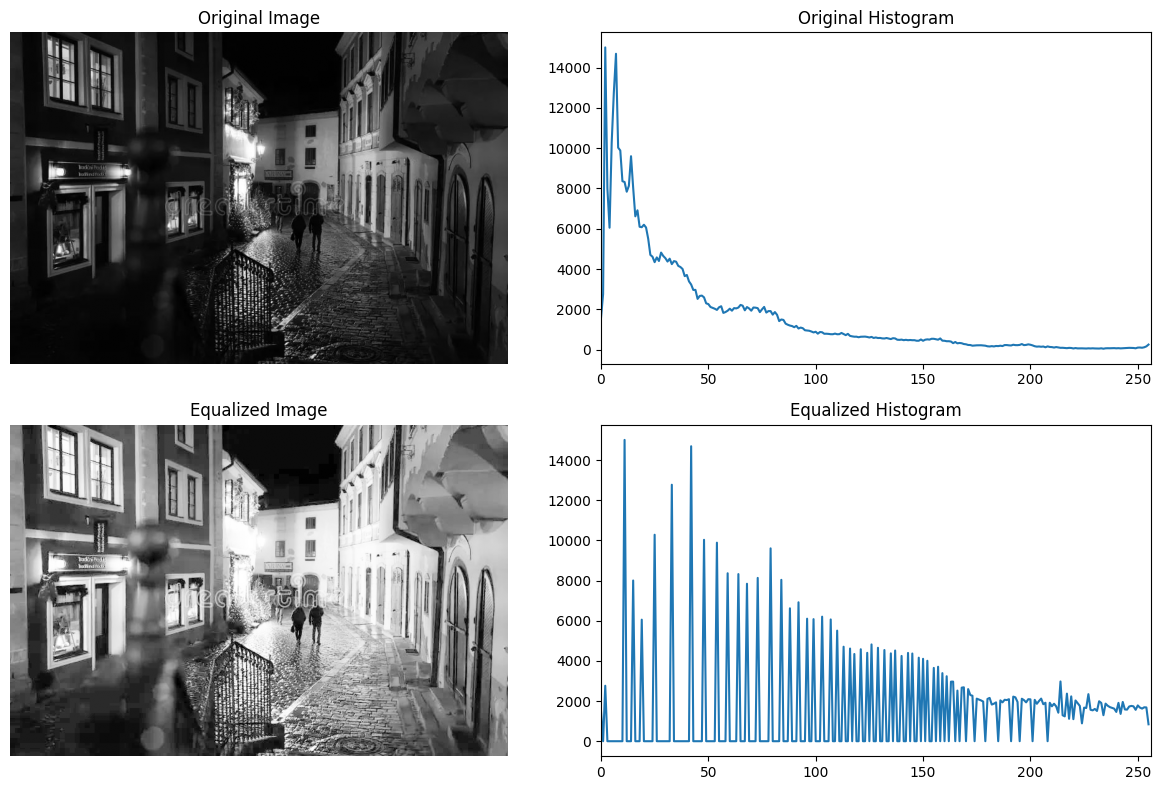


Output files saved in:
/content/drive/MyDrive/AIPA_HA/ALM-3/Assignment_2_Histogram


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

base_dir = Path("/content/drive/MyDrive/AIPA_HA/ALM-3")
output_dir = base_dir / "Assignment_2_Histogram"
output_dir.mkdir(parents=True, exist_ok=True)

image1_path = base_dir / "Histogram_image_1.png"

if not image1_path.exists():
    print("Image 1 was not found.")
    print("Files available in the folder:")
    for file in base_dir.iterdir():
        print(file.name)
    raise FileNotFoundError("Histogram image 1 not found.")


image_files = []

for file in base_dir.iterdir():
    if file.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp"]:
        image_files.append(file)

image2_candidates = [
    file for file in image_files
    if file.name.lower() != "histogram_image_1.png"
    and "histogram" in file.name.lower()
]

if len(image2_candidates) == 0:
    print("Image 2 was not found.")
    print("\nImages available in the folder:")

    for file in image_files:
        print(file.name)

    raise FileNotFoundError(
        "Could not find the second histogram image."
    )

image2_path = image2_candidates[0]

print("Image 1:", image1_path.name)
print("Image 2:", image2_path.name)


def process_image(image_path, name):

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        raise FileNotFoundError(
            f"Could not read image: {image_path}"
        )

    equalized = cv2.equalizeHist(image)

    cv2.imwrite(
        str(output_dir / f"{name}_original.png"),
        image
    )

    cv2.imwrite(
        str(output_dir / f"{name}_equalized.png"),
        equalized
    )

    hist_original = cv2.calcHist(
        [image],
        [0],
        None,
        [256],
        [0, 256]
    )

    hist_equalized = cv2.calcHist(
        [equalized],
        [0],
        None,
        [256],
        [0, 256]
    )

    plt.figure(figsize=(10, 5))
    plt.plot(hist_original)
    plt.title(f"{name} Original Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.xlim([0, 256])
    plt.tight_layout()

    plt.savefig(
        str(output_dir / f"{name}_original_histogram.png"),
        dpi=200
    )

    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(hist_equalized)
    plt.title(f"{name} Equalized Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.xlim([0, 256])
    plt.tight_layout()

    plt.savefig(
        str(output_dir / f"{name}_equalized_histogram.png"),
        dpi=200
    )

    plt.show()

    print()
    print(name)
    print("Original mean:", round(np.mean(image), 2))
    print(
        "Original standard deviation:",
        round(np.std(image), 2)
    )
    print("Equalized mean:", round(np.mean(equalized), 2))
    print(
        "Equalized standard deviation:",
        round(np.std(equalized), 2)
    )

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.plot(hist_original)
    plt.title("Original Histogram")
    plt.xlim([0, 256])

    plt.subplot(2, 2, 3)
    plt.imshow(equalized, cmap="gray")
    plt.title("Equalized Image")
    plt.axis("off")

    plt.subplot(2, 2, 4)
    plt.plot(hist_equalized)
    plt.title("Equalized Histogram")
    plt.xlim([0, 256])

    plt.tight_layout()
    plt.show()


process_image(
    image1_path,
    "Image_1_Low_Contrast"
)

process_image(
    image2_path,
    "Image_2_Normal_High_Contrast"
)

print()
print("Output files saved in:")
print(output_dir)

## Assignment 3 — Hough Line and Circle Detection

# Part A — Hough Line Detection

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

base_dir = Path("/content/drive/MyDrive/AIPA_HA/ALM-3")
image_path = base_dir / "Hough_Lines.png"

output_dir = base_dir / "Assignment_3_Hough_Lines"
output_dir.mkdir(parents=True, exist_ok=True)

image = cv2.imread(str(image_path))

if image is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(
    gray,
    (5, 5),
    0
)

edges = cv2.Canny(
    blurred,
    50,
    150
)

cv2.imwrite(
    str(output_dir / "edges.png"),
    edges
)

settings = [
    {
        "name": "Setting_1",
        "threshold": 50,
        "minLineLength": 50,
        "maxLineGap": 10
    },
    {
        "name": "Setting_2",
        "threshold": 80,
        "minLineLength": 80,
        "maxLineGap": 15
    },
    {
        "name": "Setting_3",
        "threshold": 110,
        "minLineLength": 120,
        "maxLineGap": 20
    }
]

results = []

for setting in settings:

    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=setting["threshold"],
        minLineLength=setting["minLineLength"],
        maxLineGap=setting["maxLineGap"]
    )

    output = image.copy()

    line_count = 0

    if lines is not None:

        lines = np.asarray(lines).reshape(-1, 4)

        line_count = len(lines)

        for x1, y1, x2, y2 in lines:

            cv2.line(
                output,
                (int(x1), int(y1)),
                (int(x2), int(y2)),
                (0, 255, 0),
                2
            )

    filename = setting["name"].lower() + ".png"

    cv2.imwrite(
        str(output_dir / filename),
        output
    )

    results.append(
        (
            setting["name"],
            setting["threshold"],
            setting["minLineLength"],
            setting["maxLineGap"],
            line_count
        )
    )

print()
print("Hough Line Detection Results")
print()

for result in results:

    print(
        result[0],
        "| Threshold:", result[1],
        "| MinLineLength:", result[2],
        "| MaxLineGap:", result[3],
        "| Lines Detected:", result[4]
    )

print()
print("Output files saved in:")
print(output_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Hough Line Detection Results

Setting_1 | Threshold: 50 | MinLineLength: 50 | MaxLineGap: 10 | Lines Detected: 224
Setting_2 | Threshold: 80 | MinLineLength: 80 | MaxLineGap: 15 | Lines Detected: 122
Setting_3 | Threshold: 110 | MinLineLength: 120 | MaxLineGap: 20 | Lines Detected: 67

Output files saved in:
/content/drive/MyDrive/AIPA_HA/ALM-3/Assignment_3_Hough_Lines


## Display the line detection results

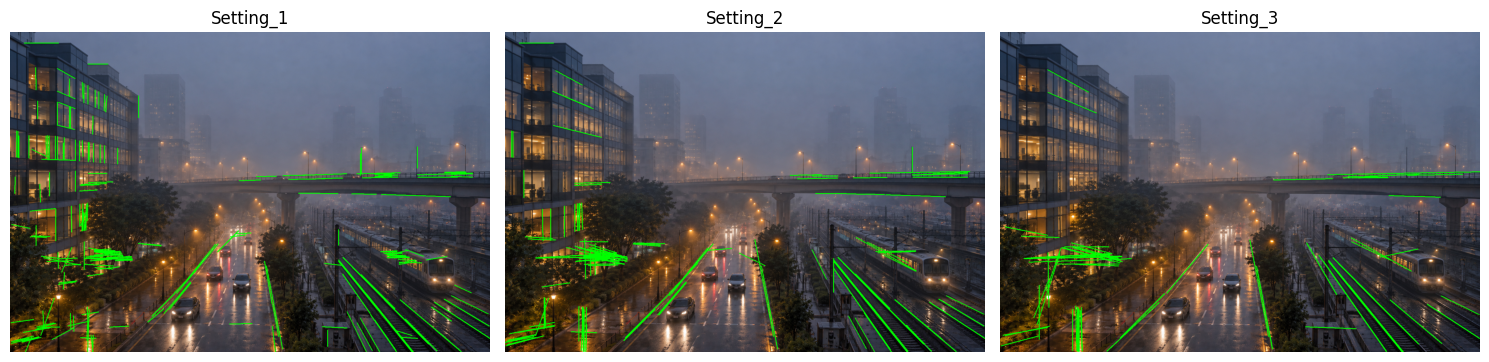

In [ ]:
plt.figure(figsize=(15, 5))

for i, setting in enumerate(settings):

    filename = setting["name"].lower() + ".png"

    result = cv2.imread(
        str(output_dir / filename)
    )

    result = cv2.cvtColor(
        result,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(1, 3, i + 1)
    plt.imshow(result)
    plt.title(setting["name"])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Assignment 3 — Hough Circle Detection

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

base_dir = Path("/content/drive/MyDrive/AIPA_HA/ALM-3")
image_path = base_dir / "Hough_Circles.png"

output_dir = base_dir / "Assignment_3_Hough_Circles"
output_dir.mkdir(parents=True, exist_ok=True)

image = cv2.imread(str(image_path))

if image is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

blurred = cv2.GaussianBlur(
    gray,
    (9, 9),
    2
)

settings = [
    {
        "name": "Setting_1",
        "dp": 1.2,
        "minDist": 30,
        "param1": 100,
        "param2": 30,
        "minRadius": 10,
        "maxRadius": 150
    },
    {
        "name": "Setting_2",
        "dp": 1.2,
        "minDist": 40,
        "param1": 120,
        "param2": 35,
        "minRadius": 10,
        "maxRadius": 150
    },
    {
        "name": "Setting_3",
        "dp": 1.0,
        "minDist": 50,
        "param1": 150,
        "param2": 40,
        "minRadius": 15,
        "maxRadius": 180
    }
]

results = []

for setting in settings:

    circles = cv2.HoughCircles(
        blurred,
        cv2.HOUGH_GRADIENT,
        dp=setting["dp"],
        minDist=setting["minDist"],
        param1=setting["param1"],
        param2=setting["param2"],
        minRadius=setting["minRadius"],
        maxRadius=setting["maxRadius"]
    )

    output = image.copy()

    circle_count = 0

    if circles is not None:

        circles = np.round(
            circles[0]
        ).astype(int)

        circle_count = len(circles)

        for x, y, radius in circles:

            cv2.circle(
                output,
                (int(x), int(y)),
                int(radius),
                (0, 255, 0),
                2
            )

            cv2.circle(
                output,
                (int(x), int(y)),
                2,
                (0, 0, 255),
                3
            )

    filename = setting["name"].lower() + ".png"

    cv2.imwrite(
        str(output_dir / filename),
        output
    )

    results.append(
        (
            setting["name"],
            setting["dp"],
            setting["minDist"],
            setting["param1"],
            setting["param2"],
            setting["minRadius"],
            setting["maxRadius"],
            circle_count
        )
    )

print()
print("Hough Circle Detection Results")
print()

for result in results:

    print(
        result[0],
        "| dp:", result[1],
        "| minDist:", result[2],
        "| param1:", result[3],
        "| param2:", result[4],
        "| minRadius:", result[5],
        "| maxRadius:", result[6],
        "| Circles Detected:", result[7]
    )

print()
print("Output files saved in:")
print(output_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Hough Circle Detection Results

Setting_1 | dp: 1.2 | minDist: 30 | param1: 100 | param2: 30 | minRadius: 10 | maxRadius: 150 | Circles Detected: 519
Setting_2 | dp: 1.2 | minDist: 40 | param1: 120 | param2: 35 | minRadius: 10 | maxRadius: 150 | Circles Detected: 241
Setting_3 | dp: 1.0 | minDist: 50 | param1: 150 | param2: 40 | minRadius: 15 | maxRadius: 180 | Circles Detected: 40

Output files saved in:
/content/drive/MyDrive/AIPA_HA/ALM-3/Assignment_3_Hough_Circles


## Display the circle results

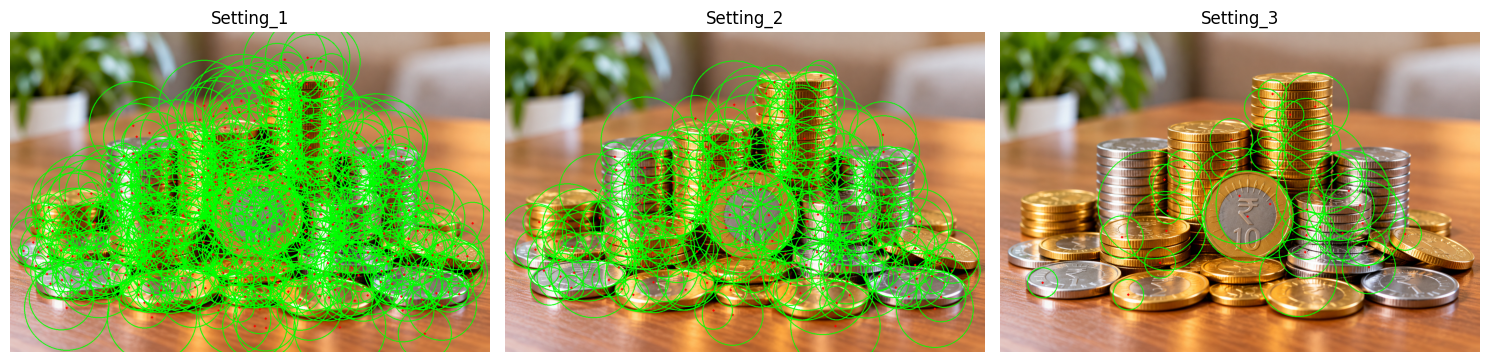

In [ ]:
plt.figure(figsize=(15, 5))

for i, setting in enumerate(settings):

    filename = setting["name"].lower() + ".png"

    result = cv2.imread(
        str(output_dir / filename)
    )

    result = cv2.cvtColor(
        result,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(1, 3, i + 1)
    plt.imshow(result)
    plt.title(setting["name"])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Assignment 4 — SIFT, SURF and ORB

In [ ]:
import numpy as np
import cv2

print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)

NumPy: 2.1.3
OpenCV: 5.0.0


In [ ]:
!pip install -q -U mahotas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 30.9 MB/s eta 0:00:00


In [ ]:
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import drive
from mahotas.features import surf

drive.mount('/content/drive')

input_path = Path(
    "/content/drive/MyDrive/AIPA_HA/ALM-3/SIFT_SURF_ORB.png"
)

output_dir = Path(
    "/content/drive/MyDrive/AIPA_HA/ALM-3/Assignment_4_Feature_Detection"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

image = cv2.imread(
    str(input_path)
)

if image is None:
    raise FileNotFoundError(
        f"Image not found: {input_path}"
    )

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

results = []


sift = cv2.SIFT_create()

start = time.perf_counter()

sift_keypoints, sift_descriptors = sift.detectAndCompute(
    gray,
    None
)

sift_time = time.perf_counter() - start

sift_output = cv2.drawKeypoints(
    image,
    sift_keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

cv2.imwrite(
    str(output_dir / "SIFT_keypoints.png"),
    sift_output
)

results.append([
    "SIFT",
    len(sift_keypoints),
    sift_descriptors.shape,
    str(sift_descriptors.dtype),
    sift_time
])


gray_surf = np.ascontiguousarray(
    gray,
    dtype=np.uint8
)

start = time.perf_counter()

surf_points = surf.surf(
    gray_surf,
    nr_octaves=4,
    nr_scales=6,
    initial_step_size=1,
    threshold=0.1,
    max_points=1024
)

surf_time = time.perf_counter() - start

surf_keypoints = len(surf_points)

surf_descriptors = surf_points[:, 6:]

surf_output = image.copy()

for point in surf_points:

    y = int(point[0])
    x = int(point[1])
    scale = max(2, int(point[2]))

    cv2.circle(
        surf_output,
        (x, y),
        scale,
        (0, 255, 0),
        1
    )

    cv2.circle(
        surf_output,
        (x, y),
        2,
        (0, 0, 255),
        -1
    )

cv2.imwrite(
    str(output_dir / "SURF_keypoints.png"),
    surf_output
)

results.append([
    "SURF",
    surf_keypoints,
    surf_descriptors.shape,
    str(surf_descriptors.dtype),
    surf_time
])


orb = cv2.ORB_create(
    nfeatures=1000
)

start = time.perf_counter()

orb_keypoints, orb_descriptors = orb.detectAndCompute(
    gray,
    None
)

orb_time = time.perf_counter() - start

orb_output = cv2.drawKeypoints(
    image,
    orb_keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

cv2.imwrite(
    str(output_dir / "ORB_keypoints.png"),
    orb_output
)

results.append([
    "ORB",
    len(orb_keypoints),
    orb_descriptors.shape,
    str(orb_descriptors.dtype),
    orb_time
])


print()
print("Feature Detection Results")
print()

for result in results:

    print("Method:", result[0])
    print("Keypoints:", result[1])
    print("Descriptor shape:", result[2])
    print("Descriptor type:", result[3])
    print(
        "Execution time:",
        f"{result[4]:.8f}",
        "seconds"
    )
    print()

print("Output files saved in:")
print(output_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Feature Detection Results

Method: SIFT
Keypoints: 7703
Descriptor shape: (7703, 128)
Descriptor type: float32
Execution time: 3.08007714 seconds

Method: SURF
Keypoints: 949
Descriptor shape: (949, 64)
Descriptor type: float64
Execution time: 2.23204859 seconds

Method: ORB
Keypoints: 1000
Descriptor shape: (1000, 32)
Descriptor type: uint8
Execution time: 0.04442107 seconds

Output files saved in:
/content/drive/MyDrive/AIPA_HA/ALM-3/Assignment_4_Feature_Detection


## Display all three

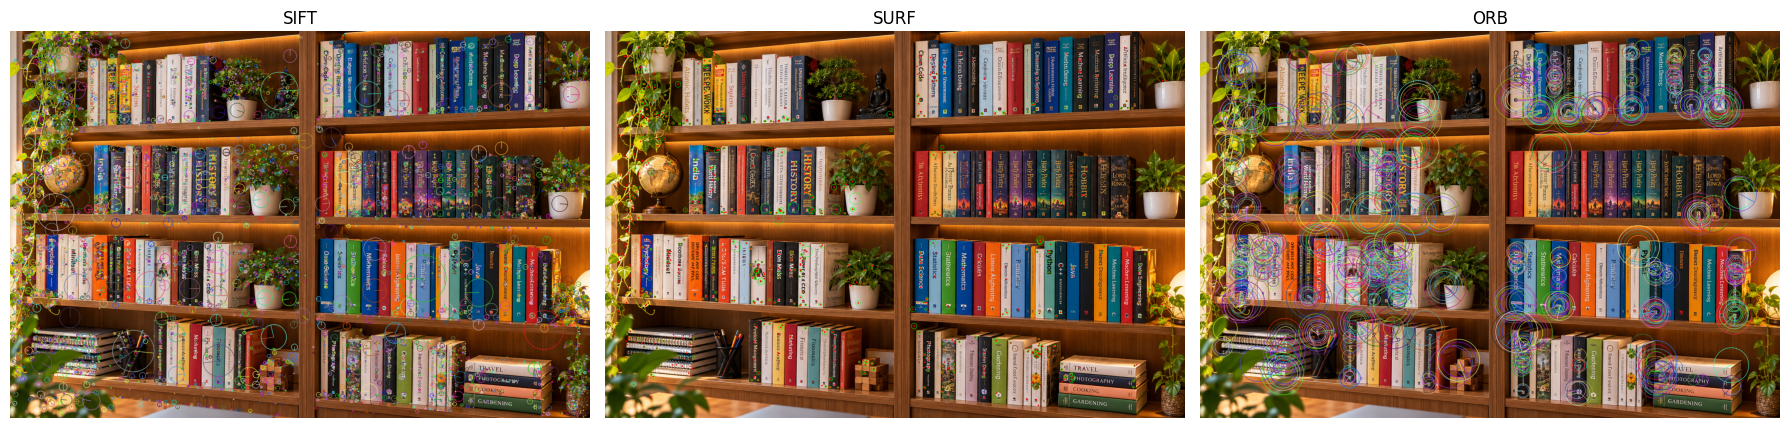

In [ ]:
import matplotlib.pyplot as plt

files = [
    ("SIFT", "SIFT_keypoints.png"),
    ("SURF", "SURF_keypoints.png"),
    ("ORB", "ORB_keypoints.png")
]

plt.figure(figsize=(18, 6))

for i, (name, filename) in enumerate(files):

    result = cv2.imread(
        str(output_dir / filename)
    )

    result = cv2.cvtColor(
        result,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(1, 3, i + 1)
    plt.imshow(result)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Assignment 5 — Object Tracking

In [ ]:
!pip install -q --upgrade opencv-contrib-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 MB 6.6 MB/s eta 0:00:00


## Loading and Inspecting the Input Video

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Video information
Width: 3840
Height: 2160
FPS: 59.94005994005994
Total frames: 2250
Duration: 37.54 seconds


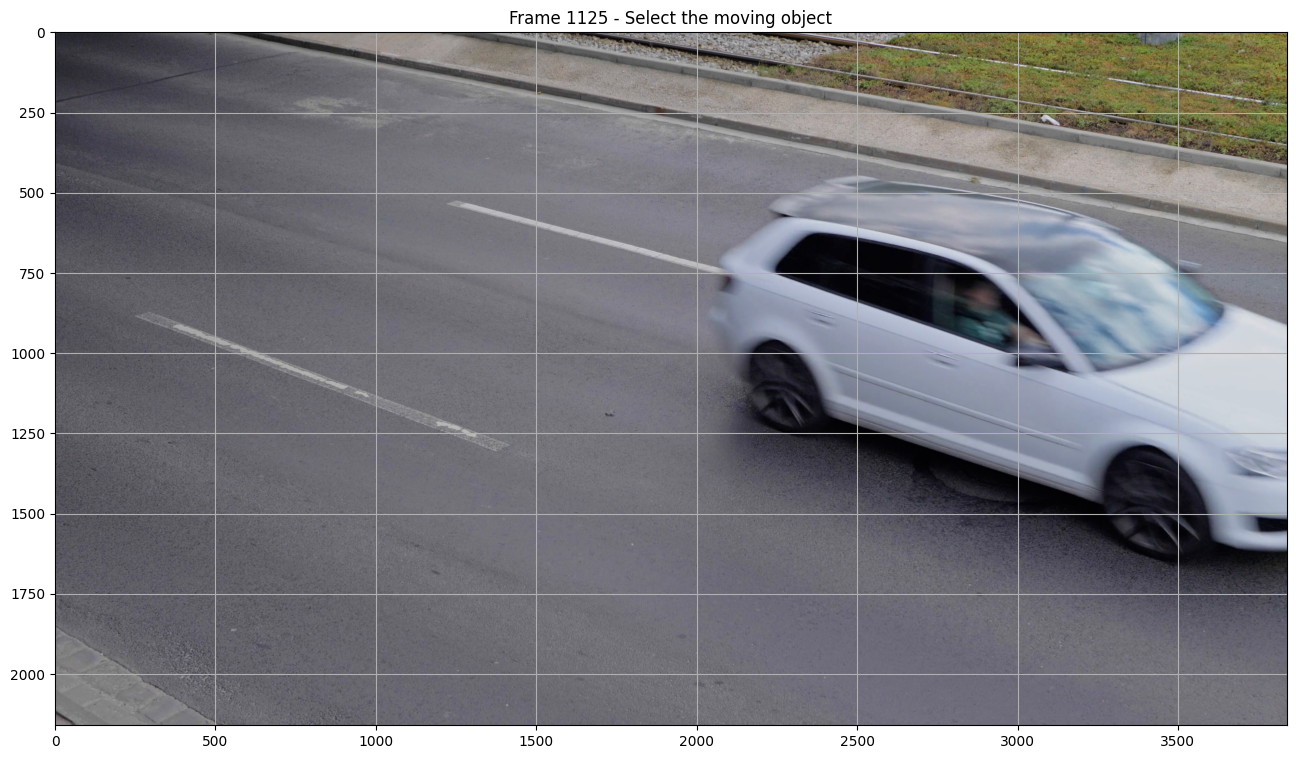


Look at the frame above.
If the moving object is clearly visible, continue.
The next cell will allow you to select it with your mouse.


In [ ]:
import cv2
import time
from pathlib import Path
from google.colab import drive
from IPython.display import Video, display
import matplotlib.pyplot as plt

drive.mount('/content/drive')

video_path = Path("/content/drive/MyDrive/AIPA_HA/ALM-3/Object Tracking.mp4")

output_dir = Path(
    "/content/drive/MyDrive/AIPA_HA/ALM-3/Assignment_5_Object_Tracking"
)
output_dir.mkdir(parents=True, exist_ok=True)

output_video = output_dir / "Tracking_Result.mp4"
selected_frame_path = output_dir / "Selected_Frame.png"

cap = cv2.VideoCapture(str(video_path))

if not cap.isOpened():
    raise FileNotFoundError("Could not open the video.")

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("Video information")
print("Width:", width)
print("Height:", height)
print("FPS:", fps)
print("Total frames:", total_frames)
print("Duration:", round(total_frames / fps, 2), "seconds")

# Show a frame from the middle of the video
frame_number = total_frames // 2

cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

ret, frame = cap.read()

if not ret:
    raise RuntimeError("Could not read the selected frame.")

display_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 9))
plt.imshow(display_frame)
plt.title(
    f"Frame {frame_number} - Select the moving object"
)
plt.axis("on")
plt.grid()
plt.show()

cap.release()

print()
print("Look at the frame above.")
print("If the moving object is clearly visible, continue.")
print("The next cell will allow you to select it with your mouse.")

## Selecting the Object for Tracking

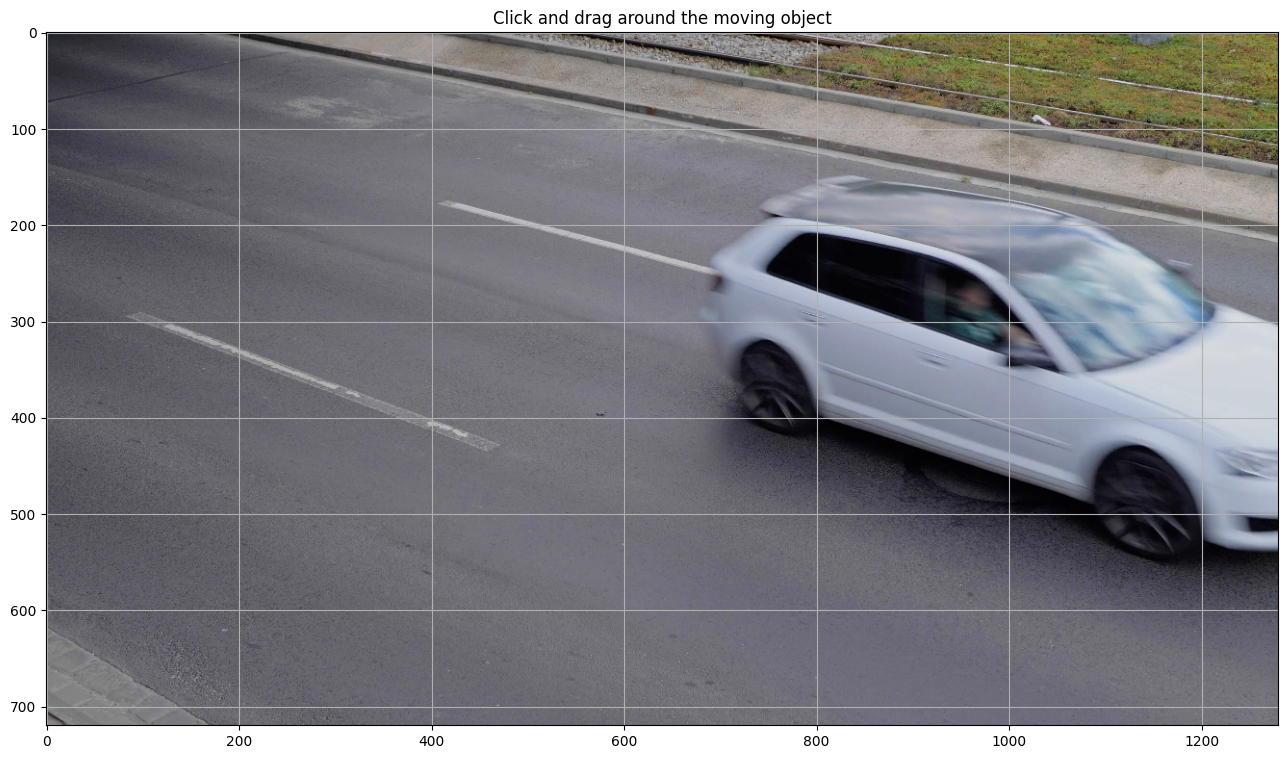


If the object is visible above, enter its bounding box.
Format: x,y,width,height
Coordinates are for the displayed 1280-pixel-wide image.


In [ ]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(str(video_path))

frame_number = total_frames // 2
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

ret, frame = cap.read()

if not ret:
    raise RuntimeError("Could not read the selected frame.")

# Resize for easier selection
display_width = 1280
scale = display_width / width
display_height = int(height * scale)

small_frame = cv2.resize(
    frame,
    (display_width, display_height)
)

small_rgb = cv2.cvtColor(small_frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 9))
plt.imshow(small_rgb)
plt.title(
    "Click and drag around the moving object"
)
plt.axis("on")
plt.grid()
plt.show()

print()
print("If the object is visible above, enter its bounding box.")
print("Format: x,y,width,height")
print("Coordinates are for the displayed 1280-pixel-wide image.")

# Checking Different Video Frames for a Moving Object

In [ ]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(str(video_path))

frames_to_check = [
    200,
    400,
    600,
    800,
    1000,
    1200,
    1400,
    1600,
    1800,
    2000
]

for number in frames_to_check:
    cap.set(cv2.CAP_PROP_POS_FRAMES, number)

    ret, frame = cap.read()

    if not ret:
        continue

    small = cv2.resize(frame, (1280, 720))
    rgb = cv2.cvtColor(small, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14, 7))
    plt.imshow(rgb)
    plt.title(f"Frame {number}")
    plt.axis("off")
    plt.show()

cap.release()

Output hidden; open in https://colab.research.google.com to view.